# Chapter 82 - Comparing Character, Word, and Subword Models

A GPT predicts the next token, but its tokenizer decides what one token represents.

This chapter compares character, word-like, and homemade subword representations using the same held-out documents and the same tiny model architecture.

## Learning goals

By the end of this chapter, you will be able to:

- compare vocabulary size, sequence length, and output-layer size;

- inspect actual tokens and unknown-token behavior;

- explain which representations can spell unseen words;

- measure token positions per second without confusing tokens with source text;

- interpret raw validation loss only within its tokenization;

- compare generated samples with consistent prompts and sampling settings; and

- explain why no tokenizer is universally best.

## Three prediction units

A character tokenizer represents `the cat` as `['t', 'h', 'e', ' ', 'c', 'a', 't']`.

A word-like tokenizer can represent it as `['the', ' ', 'cat']` because this chapter preserves separators as tokens.

A learned subword tokenizer may represent it as pieces such as `['the', ' cat']`, depending on its merge rules.

Smaller units usually produce longer sequences, while larger learned units usually require more vocabulary entries.

## What the experiment can and cannot compare

Each model receives the same architecture, batch size, token context length, learning rate, and 200 optimizer updates.

Several metrics still use different units:

- 32 characters, words, and subwords cover different amounts of source text.

- Token positions per second does not say how many source characters were processed.

- Cross-entropy per character, word, and subword does not measure the same event.

- The word tokenizer is lossy on unseen words because several strings map to `<unknown>`.

The results are a teaching diagnostic, not a universal tokenizer ranking.

## Build a document-level holdout

Tokenizer fitting and model training use three documents.

The final document remains unseen until validation, which avoids the leakage caused by repeating one passage before splitting it.

In [1]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]

validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""

training_text = "\n\n".join(training_documents)
validation_only_characters = sorted(set(validation_text) - set(training_text))
device = "cpu"

print("Device:", device)
print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print("Validation-only characters:", validation_only_characters)

assert not validation_only_characters

Device: cpu
Training characters: 896
Validation characters: 237
Validation-only characters: []


This homemade comparison has no byte fallback, so the local validation fixture deliberately uses only characters present in training.

## Define a simple sentence splitter

The splitter keeps punctuation with each sentence and is intentionally simpler than a production linguistic sentence segmenter.

In [2]:
def simple_sentence_split(text: str) -> list[str]:
    sentences: list[str] = []
    current_characters: list[str] = []

    for character in text:
        current_characters.append(character)
        if character in {".", "?", "!"}:
            sentence = "".join(current_characters).strip()
            if sentence:
                sentences.append(sentence)
            current_characters = []

    final_sentence = "".join(current_characters).strip()
    if final_sentence:
        sentences.append(final_sentence)
    return sentences


comparison_sentences = simple_sentence_split(training_text + "\n\n" + validation_text)

print("Corpus sentence-like units:", len(comparison_sentences))
print("First three units:")
for sentence in comparison_sentences[:3]:
    print(repr(sentence))

Corpus sentence-like units: 8
First three units:
'Alice was beginning to get very tired of sitting by her sister on the bank,\nand of having nothing to do.'
'Once or twice she had peeped into the book her\nsister was reading, but it had no pictures or conversations in it, and what is\nthe use of a book, thought Alice, without pictures or conversation?'
'So she was considering in her own mind, as well as she could, for the hot day\nmade her feel very sleepy and stupid, whether the pleasure of making a daisy\nchain would be worth the trouble of getting up and picking the daisies, when\nsuddenly a white rabbit with pink eyes ran close by her.'


## Character tokenizer

One known character becomes one token, so new words remain representable when every character is known.

In [3]:
class CharacterTokenizer:
    token_to_id: dict[str, int]
    id_to_token: dict[int, str]
    is_trained: bool

    def __init__(self) -> None:
        self.token_to_id = {}
        self.id_to_token = {}
        self.is_trained = False

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.token_to_id)

    def train(self, text: str) -> None:
        sorted_tokens = sorted(set(text))
        self.token_to_id = {
            token: token_id for token_id, token in enumerate(sorted_tokens)
        }
        self.id_to_token = {
            token_id: token for token, token_id in self.token_to_id.items()
        }
        self.is_trained = True

    def encode_to_tokens(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - set(self.token_to_id))
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")
        return list(text)

    def encode(self, text: str) -> list[int]:
        return [self.token_to_id[token] for token in self.encode_to_tokens(text)]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        return "".join(self.id_to_token[token_id] for token_id in token_ids)

## Word-like tokenizer

This teaching tokenizer groups consecutive letters and digits into words while keeping each space, newline, and punctuation mark as its own token.

An unseen word becomes `<unknown>`, so encoding succeeds but exact reconstruction becomes impossible.

In [4]:
UNKNOWN_TOKEN = "<unknown>"


def simple_word_tokenize(text: str) -> list[str]:
    tokens: list[str] = []
    current_word: list[str] = []

    for character in text:
        if character.isalnum():
            current_word.append(character)
        else:
            if current_word:
                tokens.append("".join(current_word))
                current_word = []
            tokens.append(character)

    if current_word:
        tokens.append("".join(current_word))
    return tokens


class WordTokenizer:
    unknown_token: str
    token_to_id: dict[str, int]
    id_to_token: dict[int, str]
    is_trained: bool

    def __init__(self) -> None:
        self.unknown_token = UNKNOWN_TOKEN
        self.token_to_id = {}
        self.id_to_token = {}
        self.is_trained = False

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.token_to_id)

    def train(self, text: str) -> None:
        vocabulary = set(simple_word_tokenize(text)) | {self.unknown_token}
        sorted_tokens = sorted(vocabulary)
        self.token_to_id = {
            token: token_id for token_id, token in enumerate(sorted_tokens)
        }
        self.id_to_token = {
            token_id: token for token, token_id in self.token_to_id.items()
        }
        self.is_trained = True

    def encode_to_tokens(self, text: str) -> list[str]:
        self._check_trained()
        return [
            token if token in self.token_to_id else self.unknown_token
            for token in simple_word_tokenize(text)
        ]

    def encode(self, text: str) -> list[int]:
        return [self.token_to_id[token] for token in self.encode_to_tokens(text)]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        return "".join(self.id_to_token[token_id] for token_id in token_ids)

## Homemade subword tokenizer

The subword tokenizer starts from characters and repeatedly merges the most frequent adjacent pair.

Lexical tie-breaking makes its merge order deterministic.

In [5]:
from collections import Counter  # noqa: I001
from dataclasses import dataclass


TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    pair: TokenPair
    new_token: str


def count_adjacent_token_pairs(token_sequence: list[str]) -> Counter[TokenPair]:
    return Counter(zip(token_sequence, token_sequence[1:], strict=False))


def select_most_frequent_pair(pair_counts: Counter[TokenPair]) -> TokenPair:
    highest_count = max(pair_counts.values())
    return min(pair for pair, count in pair_counts.items() if count == highest_count)


def merge_pair_in_sequence(
    token_sequence: list[str],
    pair_to_merge: TokenPair,
    merged_token: str,
) -> list[str]:
    merged_sequence: list[str] = []
    position = 0

    while position < len(token_sequence):
        pair_matches = (
            position + 1 < len(token_sequence)
            and token_sequence[position] == pair_to_merge[0]
            and token_sequence[position + 1] == pair_to_merge[1]
        )
        if pair_matches:
            merged_sequence.append(merged_token)
            position += 2
        else:
            merged_sequence.append(token_sequence[position])
            position += 1
    return merged_sequence


class SubwordTokenizer:
    number_of_merges: int
    merge_rules: list[MergeRule]
    base_alphabet: set[str]
    token_to_id: dict[str, int]
    id_to_token: dict[int, str]
    is_trained: bool

    def __init__(self, number_of_merges: int) -> None:
        if number_of_merges < 0:
            raise ValueError("number_of_merges must be nonnegative.")
        self.number_of_merges = number_of_merges
        self.merge_rules = []
        self.base_alphabet = set()
        self.token_to_id = {}
        self.id_to_token = {}
        self.is_trained = False

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.token_to_id)

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        token_sequence = list(text)
        vocabulary = set(token_sequence)
        merge_rules: list[MergeRule] = []

        for _ in range(self.number_of_merges):
            pair_counts = count_adjacent_token_pairs(token_sequence)
            if not pair_counts:
                break
            pair_to_merge = select_most_frequent_pair(pair_counts)
            new_token = "".join(pair_to_merge)
            if new_token in vocabulary:
                raise RuntimeError(f"Merge token collision for {new_token!r}.")
            token_sequence = merge_pair_in_sequence(
                token_sequence,
                pair_to_merge,
                new_token,
            )
            merge_rules.append(MergeRule(pair_to_merge, new_token))
            vocabulary.add(new_token)

        sorted_tokens = sorted(vocabulary)
        self.merge_rules = merge_rules
        self.base_alphabet = set(text)
        self.token_to_id = {
            token: token_id for token_id, token in enumerate(sorted_tokens)
        }
        self.id_to_token = {
            token_id: token for token, token_id in self.token_to_id.items()
        }
        self.is_trained = True

    def encode_to_tokens(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - self.base_alphabet)
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")

        token_sequence = list(text)
        for merge_rule in self.merge_rules:
            token_sequence = merge_pair_in_sequence(
                token_sequence,
                merge_rule.pair,
                merge_rule.new_token,
            )
        return token_sequence

    def encode(self, text: str) -> list[int]:
        return [self.token_to_id[token] for token in self.encode_to_tokens(text)]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        return "".join(self.id_to_token[token_id] for token_id in token_ids)

## Train all three tokenizers on the same text

Only training documents determine characters, words, merge rules, and integer IDs.

In [6]:
character_tokenizer = CharacterTokenizer()
character_tokenizer.train(training_text)

word_tokenizer = WordTokenizer()
word_tokenizer.train(training_text)

subword_tokenizer = SubwordTokenizer(number_of_merges=120)
subword_tokenizer.train(training_text)

character_training_ids = character_tokenizer.encode(training_text)
character_validation_ids = character_tokenizer.encode(validation_text)
word_training_ids = word_tokenizer.encode(training_text)
word_validation_ids = word_tokenizer.encode(validation_text)
subword_training_ids = subword_tokenizer.encode(training_text)
subword_validation_ids = subword_tokenizer.encode(validation_text)

print("tokenizer | vocabulary | train tokens | validation tokens")
print("-" * 62)


def print_dataset_summary(
    name: str,
    vocabulary_size: int,
    training_ids: list[int],
    validation_ids: list[int],
) -> None:
    print(
        f"{name:<9} | {vocabulary_size:>10} | "
        f"{len(training_ids):>12} | {len(validation_ids):>17}"
    )


print_dataset_summary(
    "character",
    character_tokenizer.vocabulary_size,
    character_training_ids,
    character_validation_ids,
)
print_dataset_summary(
    "word",
    word_tokenizer.vocabulary_size,
    word_training_ids,
    word_validation_ids,
)
print_dataset_summary(
    "subword",
    subword_tokenizer.vocabulary_size,
    subword_training_ids,
    subword_validation_ids,
)

assert character_tokenizer.decode(character_training_ids) == training_text
assert subword_tokenizer.decode(subword_training_ids) == training_text
assert character_tokenizer.decode(character_validation_ids) == validation_text
assert subword_tokenizer.decode(subword_validation_ids) == validation_text

tokenizer | vocabulary | train tokens | validation tokens
--------------------------------------------------------------
character |         35 |          896 |               237
word      |        117 |          372 |                90
subword   |        155 |          374 |               152


The exact vocabulary ordering depends on this small corpus and merge budget, so the notebook measures rather than assumes which non-character vocabulary is larger.

## Compare actual token sequences

The first sentence uses only words seen during training, which keeps the structural comparison separate from unknown-word behavior.

In [7]:
known_sentence = "Alice was beginning."

print("Text:", repr(known_sentence))
print("Character tokens:", character_tokenizer.encode_to_tokens(known_sentence))
print("Word tokens:", word_tokenizer.encode_to_tokens(known_sentence))
print("Subword tokens:", subword_tokenizer.encode_to_tokens(known_sentence))

Text: 'Alice was beginning.'
Character tokens: ['A', 'l', 'i', 'c', 'e', ' ', 'w', 'a', 's', ' ', 'b', 'e', 'g', 'i', 'n', 'n', 'i', 'n', 'g', '.']
Word tokens: ['Alice', ' ', 'was', ' ', 'beginning', '.']
Subword tokens: ['Alice ', 'was ', 'b', 'e', 'g', 'in', 'n', 'ing', '.']


## Compare unseen-word behavior

`spaceship` was absent from tokenizer training, but every character in this test sentence is known.

In [8]:
unseen_word_text = "Alice saw the spaceship."

character_unseen_tokens = character_tokenizer.encode_to_tokens(unseen_word_text)
word_unseen_tokens = word_tokenizer.encode_to_tokens(unseen_word_text)
subword_unseen_tokens = subword_tokenizer.encode_to_tokens(unseen_word_text)

print("Text:", repr(unseen_word_text))
print("Character tokens:", character_unseen_tokens)
print("Word tokens:", word_unseen_tokens)
print("Subword tokens:", subword_unseen_tokens)
print(
    "Word decode:", repr(word_tokenizer.decode(word_tokenizer.encode(unseen_word_text)))
)

assert UNKNOWN_TOKEN in word_unseen_tokens
assert "".join(character_unseen_tokens) == unseen_word_text
assert "".join(subword_unseen_tokens) == unseen_word_text
assert (
    word_tokenizer.decode(word_tokenizer.encode(unseen_word_text)) != unseen_word_text
)

Text: 'Alice saw the spaceship.'
Character tokens: ['A', 'l', 'i', 'c', 'e', ' ', 's', 'a', 'w', ' ', 't', 'h', 'e', ' ', 's', 'p', 'a', 'c', 'e', 's', 'h', 'i', 'p', '.']
Word tokens: ['Alice', ' ', '<unknown>', ' ', 'the', ' ', '<unknown>', '.']
Subword tokens: ['Alice ', 's', 'a', 'w', ' the ', 's', 'p', 'a', 'c', 'e', 's', 'h', 'i', 'p', '.']
Word decode: 'Alice <unknown> the <unknown>.'


Character and subword tokens spell the new strings from known characters.

The word tokenizer replaces both unseen words with the same fallback, so it cannot reconstruct which words were present.

## Measure structural tradeoffs

Average tokens per sentence measures representation length across the embedded corpus's sentence-like units.

The output-layer parameter count includes both the weight matrix and bias for an untied linear layer.

In [9]:
from typing import Protocol


class ComparisonTokenizer(Protocol):
    @property
    def vocabulary_size(self) -> int: ...

    def encode_to_tokens(self, text: str) -> list[str]: ...

    def encode(self, text: str) -> list[int]: ...

    def decode(self, token_ids: list[int]) -> str: ...


def average_tokens_per_sentence(
    tokenizer: ComparisonTokenizer,
    sentences: list[str],
) -> float:
    if not sentences:
        raise ValueError("sentences must not be empty.")
    return sum(len(tokenizer.encode(sentence)) for sentence in sentences) / len(
        sentences
    )


def unknown_token_rate(tokenizer: ComparisonTokenizer, text: str) -> float:
    tokens = tokenizer.encode_to_tokens(text)
    if not tokens:
        return 0.0
    return tokens.count(UNKNOWN_TOKEN) / len(tokens)


embedding_dimension = 64
tokenizers: dict[str, ComparisonTokenizer] = {
    "character": character_tokenizer,
    "word": word_tokenizer,
    "subword": subword_tokenizer,
}
average_sentence_tokens = {
    name: average_tokens_per_sentence(tokenizer, comparison_sentences)
    for name, tokenizer in tokenizers.items()
}
output_layer_parameters = {
    name: (embedding_dimension + 1) * tokenizer.vocabulary_size
    for name, tokenizer in tokenizers.items()
}
validation_unknown_rates = {
    name: unknown_token_rate(tokenizer, validation_text)
    for name, tokenizer in tokenizers.items()
}

print("tokenizer | vocab | avg corpus tokens/sentence | output params | unknown rate")
print("-" * 86)
for name, tokenizer in tokenizers.items():
    print(
        f"{name:<9} | {tokenizer.vocabulary_size:>5} | "
        f"{average_sentence_tokens[name]:>30.2f} | "
        f"{output_layer_parameters[name]:>13} | "
        f"{validation_unknown_rates[name]:>11.1%}"
    )

tokenizer | vocab | avg corpus tokens/sentence | output params | unknown rate
--------------------------------------------------------------------------------------
character |    35 |                         140.62 |          2275 |        0.0%
word      |   117 |                          56.75 |          7605 |       23.3%
subword   |   155 |                          65.62 |         10075 |        0.0%


The word unknown rate quantifies information loss instead of hiding it behind a successful `encode` call.

## Plot vocabulary and sequence length

The two panels show the central tradeoff without duplicating the output-layer plot, whose size is exactly proportional to vocabulary size at fixed embedding dimension.

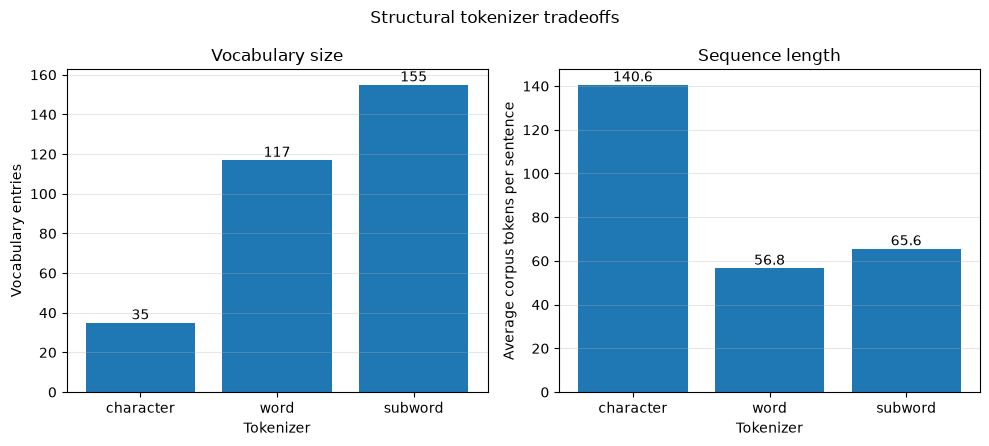

In [10]:
import matplotlib.pyplot as plt  # noqa: I001


figure, axes = plt.subplots(1, 2, figsize=(10, 4.5))

vocabulary_bars = axes[0].bar(
    tokenizers.keys(),
    [tokenizer.vocabulary_size for tokenizer in tokenizers.values()],
)
axes[0].bar_label(vocabulary_bars)
axes[0].set_xlabel("Tokenizer")
axes[0].set_ylabel("Vocabulary entries")
axes[0].set_title("Vocabulary size")
axes[0].grid(axis="y", alpha=0.3)

length_bars = axes[1].bar(
    tokenizers.keys(),
    [average_sentence_tokens[name] for name in tokenizers],
)
axes[1].bar_label(length_bars, fmt="%.1f")
axes[1].set_xlabel("Tokenizer")
axes[1].set_ylabel("Average corpus tokens per sentence")
axes[1].set_title("Sequence length")
axes[1].grid(axis="y", alpha=0.3)

figure.suptitle("Structural tokenizer tradeoffs")
figure.tight_layout()
plt.show()

## Convert each dataset to tensors

Every model receives one-dimensional CPU tensors of training and held-out IDs.

In [11]:
import torch  # noqa: I001


training_tensors = {
    "character": torch.tensor(character_training_ids, dtype=torch.long),
    "word": torch.tensor(word_training_ids, dtype=torch.long),
    "subword": torch.tensor(subword_training_ids, dtype=torch.long),
}
validation_tensors = {
    "character": torch.tensor(character_validation_ids, dtype=torch.long),
    "word": torch.tensor(word_validation_ids, dtype=torch.long),
    "subword": torch.tensor(subword_validation_ids, dtype=torch.long),
}

for name in tokenizers:
    print(
        f"{name:<9} train={tuple(training_tensors[name].shape)} "
        f"validation={tuple(validation_tensors[name].shape)}"
    )
    assert training_tensors[name].max().item() < tokenizers[name].vocabulary_size
    assert validation_tensors[name].max().item() < tokenizers[name].vocabulary_size

character train=(896,) validation=(237,)
word      train=(372,) validation=(90,)
subword   train=(374,) validation=(152,)


## Define the comparison protocol

The configuration is smaller than Chapter 81 because three models must train in one CPU notebook.

Each model still receives exactly 200 optimizer updates.

In [12]:
from typing import TypedDict


class ComparisonConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    training_steps: int
    evaluation_interval: int


comparison_config: ComparisonConfig = {
    "context_length": 32,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 1,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "training_steps": 200,
    "evaluation_interval": 50,
}

print(comparison_config)

{'context_length': 32, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 1, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.0003, 'training_steps': 200, 'evaluation_interval': 50}


## Build shifted batches

The same indexed batch builder works for all three one-dimensional token streams.

In [13]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_valid_starts = token_ids.numel() - context_length
    if number_of_valid_starts < 1:
        raise ValueError("Token stream must be longer than context_length.")

    start_indexes = torch.randint(
        0,
        number_of_valid_starts,
        (batch_size,),
        generator=generator,
    )
    offsets = torch.arange(context_length)
    input_indexes = start_indexes[:, None] + offsets[None, :]
    return token_ids[input_indexes], token_ids[input_indexes + 1]


test_generator = torch.Generator().manual_seed(82)
test_inputs, test_targets = get_gpt_training_batch(
    training_tensors["subword"],
    batch_size=8,
    context_length=32,
    generator=test_generator,
)

print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))

assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (8, 32)
Target shift correct: True


## Define the shared TinyGPT architecture

The same causal Transformer is instantiated three times, with only vocabulary-dependent dimensions changing.

In [14]:
import math


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = self.attention_dropout(
            torch.softmax(attention_scores, dim=-1)
        )
        attended_values = attention_weights @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                sequence_length,
                self.embedding_dimension,
            )
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values


class FeedForward(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension,
            number_of_attention_heads,
            context_length,
            dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForward(embedding_dimension, dropout_rate)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        values_after_attention = input_values + self.attention(
            self.attention_norm(input_values)
        )
        output_values: torch.Tensor = values_after_attention + self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension,
                    number_of_attention_heads,
                    context_length,
                    dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        for block in self.blocks:
            hidden_values = block(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))

        loss = None
        if target_token_ids is not None:
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = 10,
    ) -> torch.Tensor:
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1, :] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None],
                    float("-inf"),
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities,
                num_samples=1,
                generator=generator,
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids


def count_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

## Train and measure one model per tokenizer

Validation uses the same fixed held-out batches at every checkpoint for each model.

The timer accumulates optimizer-update work only, excluding evaluation and generation.

Throughput remains machine-dependent even with one CPU thread, so rerunning this notebook can change its measured values.

In [15]:
import time  # noqa: I001


@dataclass
class ComparisonResult:
    model: TinyGPT
    evaluation_steps: list[int]
    validation_losses: list[float]
    tokens_per_second: float
    source_character_positions_per_second: float
    generated_text: str
    optimizer_updates: int


def create_comparison_model(
    vocabulary_size: int,
    config: ComparisonConfig,
    seed: int,
) -> TinyGPT:
    torch.manual_seed(seed)
    return TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=config["dropout_rate"],
    )


@torch.no_grad()
def estimate_validation_loss(
    model: TinyGPT,
    validation_token_ids: torch.Tensor,
    config: ComparisonConfig,
    evaluation_batches: int,
    seed: int,
) -> float:
    was_training = model.training
    model.eval()
    evaluation_generator = torch.Generator().manual_seed(seed)
    losses: list[float] = []

    for _ in range(evaluation_batches):
        input_batch, target_batch = get_gpt_training_batch(
            validation_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            generator=evaluation_generator,
        )
        _, loss = model(input_batch, target_batch)
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Validation produced a non-finite loss.")
        losses.append(float(loss.item()))

    model.train(was_training)
    return sum(losses) / len(losses)


@torch.no_grad()
def generate_comparison_text(
    model: TinyGPT,
    tokenizer: ComparisonTokenizer,
    prompt: str,
    number_of_new_tokens: int,
    seed: int,
) -> str:
    was_training = model.training
    model.eval()
    prompt_ids = tokenizer.encode(prompt)
    generation_generator = torch.Generator().manual_seed(seed)
    generated_ids = model.generate(
        torch.tensor([prompt_ids], dtype=torch.long),
        number_of_new_tokens=number_of_new_tokens,
        generator=generation_generator,
    )
    model.train(was_training)
    return tokenizer.decode(generated_ids[0].tolist())


def train_for_comparison(
    tokenizer_name: str,
    tokenizer: ComparisonTokenizer,
    training_token_ids: torch.Tensor,
    validation_token_ids: torch.Tensor,
    config: ComparisonConfig,
    prompt: str,
    source_character_count: int,
    training_seed: int,
) -> ComparisonResult:
    model = create_comparison_model(
        tokenizer.vocabulary_size,
        config,
        seed=8200,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])
    training_generator = torch.Generator().manual_seed(training_seed)
    evaluation_steps: list[int] = []
    validation_losses: list[float] = []
    measured_training_seconds = 0.0
    optimizer_updates = 0

    def record_validation(step: int) -> None:
        validation_loss = estimate_validation_loss(
            model,
            validation_token_ids,
            config,
            evaluation_batches=5,
            seed=8300,
        )
        evaluation_steps.append(step)
        validation_losses.append(validation_loss)
        print(
            f"{tokenizer_name:<9} | step {step:>3} | "
            f"validation loss {validation_loss:.4f}"
        )

    torch.manual_seed(training_seed)
    model.train()
    record_validation(step=0)

    for step in range(1, config["training_steps"] + 1):
        update_start = time.perf_counter()
        input_batch, target_batch = get_gpt_training_batch(
            training_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            generator=training_generator,
        )
        logits, loss = model(input_batch, target_batch)
        if logits.shape[-1] != tokenizer.vocabulary_size:
            raise RuntimeError("Logit dimension does not match tokenizer vocabulary.")
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training produced a non-finite loss.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        measured_training_seconds += time.perf_counter() - update_start
        optimizer_updates += 1

        if step % config["evaluation_interval"] == 0:
            record_validation(step)

    processed_token_positions = (
        config["batch_size"] * config["context_length"] * optimizer_updates
    )
    tokens_per_second = processed_token_positions / measured_training_seconds
    average_characters_per_token = source_character_count / training_token_ids.numel()
    source_character_positions_per_second = (
        tokens_per_second * average_characters_per_token
    )
    generated_text = generate_comparison_text(
        model,
        tokenizer,
        prompt,
        number_of_new_tokens=60,
        seed=8400,
    )

    if optimizer_updates != config["training_steps"]:
        raise RuntimeError("Incorrect optimizer-update count.")
    return ComparisonResult(
        model=model,
        evaluation_steps=evaluation_steps,
        validation_losses=validation_losses,
        tokens_per_second=tokens_per_second,
        source_character_positions_per_second=source_character_positions_per_second,
        generated_text=generated_text,
        optimizer_updates=optimizer_updates,
    )

One CPU thread reduces scheduling noise and makes the local comparison easier to reproduce.

It does not make throughput portable to another machine.

In [16]:
torch.set_num_threads(1)

comparison_results: dict[str, ComparisonResult] = {}
for result_index, name in enumerate(tokenizers):
    comparison_results[name] = train_for_comparison(
        tokenizer_name=name,
        tokenizer=tokenizers[name],
        training_token_ids=training_tensors[name],
        validation_token_ids=validation_tensors[name],
        config=comparison_config,
        prompt="Alice",
        source_character_count=len(training_text),
        training_seed=8500 + result_index,
    )

print()
for name, result in comparison_results.items():
    print(
        f"{name:<9} | {result.tokens_per_second:>9.1f} token positions/s | "
        f"{result.source_character_positions_per_second:>9.1f} "
        "source-character positions/s"
    )
    assert result.optimizer_updates == 200

character | step   0 | validation loss 3.6598


character | step  50 | validation loss 3.0887


character | step 100 | validation loss 2.8728


character | step 150 | validation loss 2.7671


character | step 200 | validation loss 2.6917
word      | step   0 | validation loss 4.6502


...

word      | step 200 | validation loss 2.8745
subword   | step   0 | validation loss 5.1875


subword   | step  50 | validation loss 4.8578


subword   | step 100 | validation loss 4.5749


subword   | step 150 | validation loss 4.4647


subword   | step 200 | validation loss 4.4110

character |   48427.2 token positions/s |   48427.2 source-character positions/s
word      |   47988.1 token positions/s |  115584.3 source-character positions/s
subword   |   46496.7 token positions/s |  111393.1 source-character positions/s


Token positions per second measures model work at the chosen tensor shape.

The source-character-position rate multiplies it by the training corpus's average characters per token, so it is an estimate of represented text rather than a count of unique characters read.

## Inspect generated samples

All models use the same prompt, sampling seed, temperature, top-k setting, and number of generated tokens.

The decoded character lengths differ because token coverage differs.

In [17]:
for name, result in comparison_results.items():
    print("=" * 72)
    print(name.upper())
    print("=" * 72)
    print(result.generated_text)
    print("Decoded characters:", len(result.generated_text))

CHARACTER
Aliced t dr thin thhtaited atitstisthhe inteln o de hthinnsitsoub
Decoded characters: 65
WORD
Alice the her a and the,, the it, and of the or and of the very a hersister it had the her very; the the the her
it 
Decoded characters: 116
SUBWORD
Aliceitat issnupwch
me lwnu  itahays  a we she was ade oritOh dear! Iaitshe haOh dear! polh, wito itorohseedOh dear! she halok
Decoded characters: 126


Character generation can invent spellings one character at a time.

Word generation selects whole known vocabulary entries but can emit `<unknown>` and cannot construct an unseen word internally.

Subword generation combines learned chunks while retaining character fallbacks for this known alphabet.

One tiny random sample is illustrative rather than a reliable quality score.

## Print the final comparison table

The table combines structural facts, machine-dependent throughput, raw held-out loss, and cautious sample notes.

In [18]:
sample_quality_notes = {
    "character": "free spelling; errors can occur inside words",
    "word": "whole known tokens; unknown output is possible",
    "subword": "learned chunks with character fallback",
}

print(
    "tokenizer | vocab | avg tok/sentence | output params | tok/s | "
    "source char/s | raw val loss | sample note"
)
print("-" * 145)
for name, tokenizer in tokenizers.items():
    result = comparison_results[name]
    print(
        f"{name:<9} | {tokenizer.vocabulary_size:>5} | "
        f"{average_sentence_tokens[name]:>16.2f} | "
        f"{output_layer_parameters[name]:>13} | "
        f"{result.tokens_per_second:>5.0f} | "
        f"{result.source_character_positions_per_second:>13.0f} | "
        f"{result.validation_losses[-1]:>12.4f} | "
        f"{sample_quality_notes[name]}"
    )

tokenizer | vocab | avg tok/sentence | output params | tok/s | source char/s | raw val loss | sample note
-------------------------------------------------------------------------------------------------------------------------------------------------
character |    35 |           140.62 |          2275 | 48427 |         48427 |       2.6917 | free spelling; errors can occur inside words
word      |   117 |            56.75 |          7605 | 47988 |        115584 |       2.8745 | whole known tokens; unknown output is possible
subword   |   155 |            65.62 |         10075 | 46497 |        111393 |       4.4110 | learned chunks with character fallback


The output-layer column counts `(embedding_dimension + 1) * vocabulary_size` parameters for this model's untied weight and bias.

## Plot two throughput units

The left panel answers how quickly fixed token tensors are processed.

The right panel estimates how much source text those token positions represent.

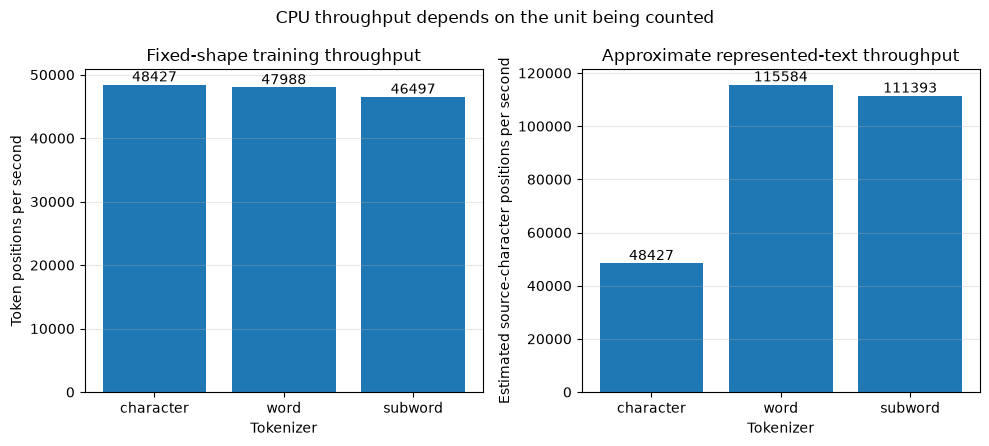

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4.5))

token_speed_bars = axes[0].bar(
    tokenizers.keys(),
    [comparison_results[name].tokens_per_second for name in tokenizers],
)
axes[0].bar_label(token_speed_bars, fmt="%.0f")
axes[0].set_xlabel("Tokenizer")
axes[0].set_ylabel("Token positions per second")
axes[0].set_title("Fixed-shape training throughput")
axes[0].grid(axis="y", alpha=0.3)

character_speed_bars = axes[1].bar(
    tokenizers.keys(),
    [
        comparison_results[name].source_character_positions_per_second
        for name in tokenizers
    ],
)
axes[1].bar_label(character_speed_bars, fmt="%.0f")
axes[1].set_xlabel("Tokenizer")
axes[1].set_ylabel("Estimated source-character positions per second")
axes[1].set_title("Approximate represented-text throughput")
axes[1].grid(axis="y", alpha=0.3)

figure.suptitle("CPU throughput depends on the unit being counted")
figure.tight_layout()
plt.show()

The two rankings can differ because a word or subword token usually covers more characters than a character token.

## Plot held-out loss histories

Each curve diagnoses learning for one next-token task.

Their vertical values should not be ranked directly because the prediction units, vocabularies, and word-token information loss differ.

character uniform baseline log(V) = 3.5553
word      uniform baseline log(V) = 4.7622
subword   uniform baseline log(V) = 5.0434


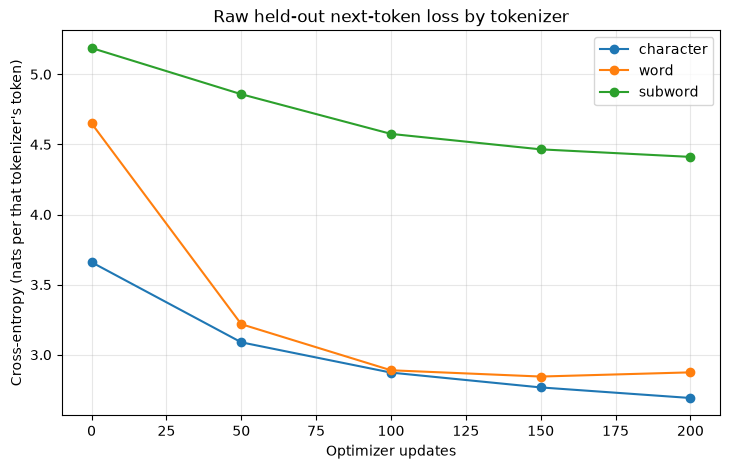

In [20]:
for name, tokenizer in tokenizers.items():
    print(
        f"{name:<9} uniform baseline log(V) = {math.log(tokenizer.vocabulary_size):.4f}"
    )

plt.figure(figsize=(8.5, 5))
for name, result in comparison_results.items():
    plt.plot(
        result.evaluation_steps,
        result.validation_losses,
        marker="o",
        label=name,
    )
plt.xlabel("Optimizer updates")
plt.ylabel("Cross-entropy (nats per that tokenizer's token)")
plt.title("Raw held-out next-token loss by tokenizer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In this run, the word model's held-out loss reaches its minimum before the final checkpoint and then rises slightly, while the other two curves are still falling at step 200.

That observation describes these short runs only and does not rank their text-level quality.

A word-level loss can look numerically different partly because one prediction may cover a whole word and unseen words are collapsed into one class.

For rigorous cross-tokenizer evaluation, use a shared text-level metric and a lossless probability accounting method; that is beyond this toy comparison.

## Verify experiment contracts

The final checks cover exact update counts, vocabulary alignment, finite losses, and each tokenizer's declared reconstruction behavior.

In [21]:
for name, tokenizer in tokenizers.items():
    result = comparison_results[name]
    assert result.optimizer_updates == comparison_config["training_steps"]
    assert result.model.vocabulary_size == tokenizer.vocabulary_size
    assert result.model.output_layer.out_features == tokenizer.vocabulary_size
    assert result.evaluation_steps == [0, 50, 100, 150, 200]
    assert all(math.isfinite(loss) for loss in result.validation_losses)
    assert result.tokens_per_second > 0

assert character_tokenizer.decode(character_validation_ids) == validation_text
assert subword_tokenizer.decode(subword_validation_ids) == validation_text
assert word_tokenizer.decode(word_validation_ids) != validation_text
assert validation_unknown_rates["word"] > 0

print("Exact optimizer updates: passed")
print("Tokenizer/model vocabulary alignment: passed")
print("Finite validation histories: passed")
print("Character and subword held-out round trips: passed")
print("Word-token information loss is detected: passed")

Exact optimizer updates: passed
Tokenizer/model vocabulary alignment: passed
Finite validation histories: passed
Character and subword held-out round trips: passed
Word-token information loss is detected: passed


## Practical decision guide

Choose characters when simplicity, spelling-level behavior, or a tiny vocabulary matters more than sequence length.

Choose word-like tokens only when the domain vocabulary is controlled and an explicit unknown or fallback policy is acceptable.

Choose subwords when you want shorter sequences than characters without making every unseen word a single unknown token.

Production systems often strengthen the subword option with byte-level fallback, normalization rules, efficient libraries, and a saved tokenizer artifact.

## Common mistakes

- Repeating one passage before a random split leaks the same content into training and validation.

- Treating `<unknown>` as lossless hides the original unseen string.

- Assuming the word vocabulary must be largest ignores corpus size and the chosen subword merge budget.

- Comparing raw cross-entropy across tokenizers as one common quality scale ignores different prediction units.

- Comparing only token positions per second ignores how much text each token covers.

- Running 201 optimizer updates in a loop configured for 200 creates an off-by-one benchmark.

- Decoding a model's IDs with another tokenizer changes their meanings.

## Takeaways

- Character tokenization has a small vocabulary and strong spelling flexibility but long sequences.

- This word-like tokenizer has shorter sequences but replaces unseen words with a lossy `<unknown>` token.

- Homemade subwords provide a measured middle ground in sequence length and preserve unseen words when their characters are known.

- Vocabulary size determines both token embeddings and output-layer dimensions.

- Throughput needs a named unit: token positions per second and represented source-character positions per second answer different questions.

- Raw validation losses diagnose each tokenizer-specific task but do not form a direct cross-tokenizer ranking.

- No tokenizer is universally best; data, task, model size, and compute constraints determine the useful tradeoff.

## What comes next

The next step is to save a trained model together with its exact tokenizer state and configuration.

That checkpoint contract preserves the meaning of every input and generated ID.